# ChestCare pneumonia: scratch-CNN run (replaces your original pneumonia notebook)

Dataset: Kermany *Chest X-ray Pneumonia* (Kaggle `paultimothymooney/chest-xray-pneumonia`), the same one your original notebook used.

**What was wrong in the original notebook (so the paper cannot rely on it)**
- The saved notebook **stops with an error** (`ValueError` at the first model's evaluation), so it holds no results for any model.
- The training generators were built with `classes=['NORMAL']` and `classes=['PNEUMONIA']` separately. Keras gives the only class in each the label 0, so **every training image was labelled 0** (this matches the exact 0.0 training loss and 100% accuracy from epoch 2).
- Validation used the 16-image Kaggle `val` folder (also all labelled 0, with augmentation), so early stopping and learning-rate reduction were meaningless.
- Augmentation was very strong for NORMAL (shifts of 40%, zoom 0.5 to 1.5, vertical flips) and mild for PNEUMONIA, which can teach the model the augmentation style instead of the disease.
- Pretrained networks received raw 0 to 255 pixels, and the classical models used 150,528 raw features.

**What this notebook does**
- Pools all 5,856 images and splits **by patient**: patient IDs are parsed from file names (`person123_...`, `IM-0115-...`), near-duplicates are also kept together, and exact duplicates (the Kaggle upload contains nested copies) are removed.
- Five-fold grouped cross-validation, correct labels, one augmentation recipe for both classes (no flips), proper input scaling, a real validation set, class weights.
- Confidence intervals, sensitivity, specificity, AUROC, calibration, shortcut probes.
- **Extra for pneumonia:** an audit of whether the official train / val / test folders share patients, and a corrected re-run of your original setup (train on official train, test once on the official 624 images) so you can report a number comparable to other papers.

**How to run on Kaggle:** GPU on, Internet ON. Run the config cell, then Run All. Optional dry run first with `SMOKE_TEST = True`.
Time: roughly 2.5 to 3.5 hours for the default settings on a P100 (my estimate from the TB run, not measured on this data).


In [1]:
# ===================== CONFIG: the only cell you normally edit =====================
import kagglehub
DATA_ROOT      = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")   # same dataset as your original notebook
DATASET        = "pneumonia"
POS_NAME, NEG_NAME = "pneumonia", "normal"
IMG_SIZE       = 224               # input size for the CNNs
N_FOLDS        = 5                 # patient-grouped, stratified cross-validation over ALL 5,856 images
SEEDS          = [42]              # [42, 43, 44] = repeated CV (3x longer)
MODELS         = ["scratch_cnn"]
USE_PRETRAINED = True              # needs Internet ON (Kaggle sidebar); falls back to random init if not
MAX_EPOCHS, PATIENCE, BATCH_SIZE = 30, 6, 32     # longer, more patient: the scratch CNN was unstable on TB
LR_SCRATCH     = 3e-4
BOOTSTRAP_B    = 2000              # bootstrap resamples for confidence intervals
DEPLOY_PREVALENCES = [0.73, 0.2, 0.05]         # PPV is also reported at these prevalences (0.73 = this dataset)
RUN_PROBES     = False              # shortcut tests (can the label be predicted without the lungs?)
RUN_LEGACY_REPLICA = False         # TB only
RUN_OFFICIAL_SPLIT = True          # also re-run your ORIGINAL setup (official train -> official 624-image test) with the fixes
EXTERNAL       = None              # optional external dataset, e.g. {"root": "/kaggle/input/<other>", "label_map": {"normal": 0, "pneumonia": 1}}
SMOKE_TEST     = False            # True = tiny dry run (a few minutes) to check the notebook works
OUT_DIR        = "results_scratch"
# ===================================================================================


### 1. Imports and settings

In [24]:
import os
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")
import io, re, json, time, math, hashlib, shutil, warnings, platform, random
from pathlib import Path
from types import SimpleNamespace
from concurrent.futures import ThreadPoolExecutor

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (roc_auc_score, average_precision_score, roc_curve,
                             precision_recall_curve)
from sklearn.ensemble import HistGradientBoostingClassifier
import tensorflow as tf
tf.get_logger().setLevel("ERROR")

warnings.filterwarnings("ignore")
try:
    from tqdm.auto import tqdm
except Exception:                                   # tqdm is optional
    def tqdm(x, **k): return x

# ---- defaults (the CONFIG cell overrides any of these) ----------------------
_DEFAULTS = dict(
    DATASET="tb", DATA_ROOT=None, SMOKE_TEST=False,
    IMG_SIZE=224, N_FOLDS=5, SEEDS=[42],
    MODELS=["scratch_cnn", "densenet121", "efficientnetb0", "pixels28_gbm"],
    USE_PRETRAINED=True, MAX_EPOCHS=12, PATIENCE=3, BATCH_SIZE=32,
    LR_SCRATCH=1e-3, LR_PRETRAINED=1e-4,
    BOOTSTRAP_B=2000, DEPLOY_PREVALENCES=[0.05],
    DUP_MAX_HAMMING=12, DUP_MIN_CORR=0.97, DROP_EXACT_DUPLICATES=True,
    RUN_PROBES=True, RUN_LEGACY_REPLICA=False,RUN_OFFICIAL_SPLIT=False,
    FOLDER_CLASSES=None, GROUP_REGEX=None, EXTERNAL=None,
    POS_NAME="positive", NEG_NAME="negative",
    OUT_DIR="/kaggle/working/results",
)
_cfg = dict(_DEFAULTS)
for _k in _DEFAULTS:
    if _k in globals():
        _cfg[_k] = globals()[_k]
CFG = SimpleNamespace(**_cfg)

if CFG.SMOKE_TEST:                                  # tiny settings to test the code path
    CFG.IMG_SIZE, CFG.N_FOLDS, CFG.MAX_EPOCHS = 64, 3, 1
    CFG.BOOTSTRAP_B, CFG.PATIENCE, CFG.BATCH_SIZE = 60, 1, 16
    CFG.USE_PRETRAINED = False

OUT = Path(CFG.OUT_DIR)
(OUT / "figures").mkdir(parents=True, exist_ok=True)
(OUT / "tables").mkdir(parents=True, exist_ok=True)
(OUT / "data").mkdir(parents=True, exist_ok=True)

def set_seed(s):
    random.seed(s); np.random.seed(s); tf.keras.utils.set_random_seed(s)

def log(*a):
    print(time.strftime("%H:%M:%S"), *a, flush=True)

gpus = tf.config.list_physical_devices("GPU")
log("TensorFlow", tf.__version__, "| GPUs:", [g.name for g in gpus] or "none (CPU only: expect slow training)")

17:05:19 TensorFlow 2.20.0 | GPUs: ['/physical_device:GPU:0', '/physical_device:GPU:1']


### 2. Find and load the images

In [3]:
LABEL_MAPS = {
    "tb":           {"normal": 0, "tuberculosis": 1},
    "cardiomegaly": {"false": 0, "true": 1},
    "pneumonia":    {"normal": 0, "pneumonia": 1},
}
IMG_EXT = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}
SPLIT_WORDS = {"train", "test", "val", "valid", "validation"}


def _label_map():
    if CFG.DATASET in LABEL_MAPS:
        return LABEL_MAPS[CFG.DATASET]
    if CFG.DATASET == "folder":
        assert CFG.FOLDER_CLASSES, "Set FOLDER_CLASSES = {'negative_folder': 0, 'positive_folder': 1}"
        return {k.lower(): v for k, v in CFG.FOLDER_CLASSES.items()}
    raise ValueError("DATASET must be tb, cardiomegaly, pneumonia or folder")


def scan_images(root, label_map):
    rows = []
    for dp, _, fs in os.walk(root):
        if "__MACOSX" in dp:
            continue
        parent = Path(dp).name.lower()
        if parent not in label_map:
            continue
        for f in fs:
            if Path(f).suffix.lower() in IMG_EXT and not f.startswith("._"):
                rows.append((os.path.join(dp, f), label_map[parent]))
    return rows


def find_rows(label_map):
    if CFG.DATA_ROOT:
        rows = scan_images(CFG.DATA_ROOT, label_map)
        found = sorted({l for _, l in rows})
        if not rows or len(found) < len(set(label_map.values())):
            where = (sorted(os.listdir(CFG.DATA_ROOT))[:20] if os.path.isdir(CFG.DATA_ROOT) else "THIS PATH DOES NOT EXIST")
            raise FileNotFoundError(
                f"DATA_ROOT={CFG.DATA_ROOT!r} gave {len(rows)} images with labels {found}. "
                f"Expected image files inside folders named {list(label_map)} (any capitalisation). "
                f"What is directly inside DATA_ROOT: {where}. Fix DATA_ROOT, or set it to None to auto-detect.")
        return rows, CFG.DATA_ROOT
    base = "/kaggle/input"
    best, best_root, best_score = [], None, 0
    for d in sorted(os.listdir(base)):
        r = scan_images(os.path.join(base, d), label_map)
        counts = pd.Series([l for _, l in r]).value_counts()
        score = int(counts.min()) if len(counts) == len(set(label_map.values())) else 0   # both classes must exist
        if score > best_score:
            best, best_root, best_score = r, os.path.join(base, d), score
    if not best:
        raise FileNotFoundError(
            f"No dataset under {base} has image folders named {list(label_map)}. "
            "Attach the dataset to the notebook (Add Input) or set DATA_ROOT.")
    return best, best_root


def patient_id(path):
    """Patient / study id when the file name carries one, else None."""
    f = Path(path).name
    if CFG.GROUP_REGEX:
        m = re.search(CFG.GROUP_REGEX, f)
        return m.group(0) if m else None
    if CFG.DATASET == "pneumonia":
        m = re.search(r"person(\d+)", f)
        if m: return "p" + m.group(1)
        m = re.search(r"IM-(\d+)", f)
        if m: return "n" + m.group(1)
    return None


def process_image(path, S):
    with open(path, "rb") as fh:
        b = fh.read()
    md5 = hashlib.md5(b).hexdigest()
    im = Image.open(io.BytesIO(b))
    w, h = im.size
    if im.mode.startswith("I"):                       # 16 bit images: rescale instead of clipping
        a = np.asarray(im).astype(np.float32)
        a = (a - a.min()) / max(1e-6, a.max() - a.min()) * 255
        g = Image.fromarray(a.astype(np.uint8))
    else:
        g = im.convert("L")
    rgb = np.asarray(Image.merge("RGB", (g, g, g)).resize((S, S), Image.BILINEAR))
    g64 = np.asarray(g.resize((64, 64), Image.BILINEAR), dtype=np.uint8)
    d = np.asarray(g.resize((17, 16), Image.LANCZOS), dtype=np.int16)      # 256 bit difference hash
    dh = np.packbits((d[:, 1:] > d[:, :-1]).ravel())
    return rgb, g64, dh, md5, w, h, len(b)


def load_dataset():
    lm = _label_map()
    rows, root = find_rows(lm)
    df = pd.DataFrame(rows, columns=["path", "label"]).sort_values("path").reset_index(drop=True)
    if CFG.SMOKE_TEST:
        df = pd.concat([df[df.label == c].sample(n=min(90, int((df.label == c).sum())), random_state=0) for c in sorted(df.label.unique())]).reset_index(drop=True)
    if len(df) == 0:
        raise FileNotFoundError("0 images were found. Check DATA_ROOT and that the dataset is attached to the notebook.")
    log(f"Found {len(df)} images under {root}: ", df.label.value_counts().sort_index().to_dict())
    N, S = len(df), CFG.IMG_SIZE
    X = np.empty((N, S, S, 3), np.uint8)
    G64 = np.empty((N, 64, 64), np.uint8)
    H = np.empty((N, 32), np.uint8)
    md5, W, Hh, NB = [], [], [], []
    workers = max(1, min(8, os.cpu_count() or 1))
    with ThreadPoolExecutor(workers) as ex:
        for i, out in enumerate(tqdm(ex.map(lambda p: process_image(p, S), df.path), total=N, desc="loading")):
            X[i], G64[i], H[i] = out[0], out[1], out[2]
            md5.append(out[3]); W.append(out[4]); Hh.append(out[5]); NB.append(out[6])
    df["md5"], df["width"], df["height"], df["nbytes"] = md5, W, Hh, NB
    df["patient_id"] = [patient_id(p) for p in df.path]
    df["orig_split"] = [next((x.lower() for x in Path(p).parts if x.lower() in SPLIT_WORDS), "") for p in df.path]
    return df, X, G64, H

### 3. Duplicate audit and grouping (replaces the "no patient IDs" gap as far as possible)

In [4]:
_POP = np.array([bin(i).count("1") for i in range(256)], dtype=np.uint8)


class UnionFind:
    def __init__(self, n): self.p = list(range(n))
    def find(self, a):
        while self.p[a] != a:
            self.p[a] = self.p[self.p[a]]; a = self.p[a]
        return a
    def union(self, a, b):
        ra, rb = self.find(a), self.find(b)
        if ra != rb: self.p[rb] = ra


def near_duplicate_pairs(H, G64, max_ham, min_corr, chunk=64):
    """Stage 1: 256-bit difference-hash candidates. Stage 2: keep pairs whose 64x64 pixel correlation is high."""
    N = len(H)
    z = G64.reshape(N, -1).astype(np.float32)
    z = (z - z.mean(1, keepdims=True)) / (z.std(1, keepdims=True) + 1e-6)
    cand = []
    for i0 in range(0, N, chunk):
        i1 = min(N, i0 + chunk)
        x = np.bitwise_xor(H[i0:i1, None, :], H[None, :, :])
        d = _POP[x].sum(axis=2, dtype=np.int32)
        ii, jj = np.where(d <= max_ham)
        for a, b in zip(ii + i0, jj):
            if a < b: cand.append((int(a), int(b)))
    pairs = []
    for a, b in cand:
        c = float(z[a] @ z[b]) / z.shape[1]
        if c >= min_corr: pairs.append((a, b, c))
    return pairs, len(cand)


def duplicate_audit(df, X, G64, H):
    N = len(df)
    info = {"n_loaded": int(N)}
    # 1) exact duplicates (identical file bytes)
    dup_mask = df.md5.duplicated(keep=False)
    conflict = df[dup_mask].groupby("md5").label.nunique()
    conflict_md5 = set(conflict[conflict > 1].index)
    info["exact_duplicate_files"] = int(dup_mask.sum())
    info["exact_duplicate_label_conflicts"] = int(len(conflict_md5))
    keep = np.ones(N, bool)
    if CFG.DROP_EXACT_DUPLICATES:
        keep &= ~df.md5.isin(conflict_md5).values            # same image, different labels: unusable
        keep &= ~df.md5.duplicated(keep="first").values       # keep one copy
        info["removed_exact_duplicates"] = int((~keep).sum())
    df, X, G64, H = df[keep].reset_index(drop=True), X[keep], G64[keep], H[keep]
    N = len(df)
    if N == 0:
        raise ValueError("Every image was removed as an exact duplicate or label conflict. Inspect df.md5 and the file paths.")
    # 2) near duplicates
    pairs, n_cand = near_duplicate_pairs(H, G64, CFG.DUP_MAX_HAMMING, CFG.DUP_MIN_CORR)
    uf = UnionFind(N)
    for a, b, _ in pairs: uf.union(a, b)
    info["near_duplicate_pairs"] = len(pairs)
    info["near_duplicate_hash_candidates"] = int(n_cand)
    info["near_duplicate_label_conflicts"] = int(sum(df.label[a] != df.label[b] for a, b, _ in pairs))
    # 3) patient ids from file names, when present
    pid = df.patient_id.fillna("")
    first = {}
    for i, p in enumerate(pid):
        if p:
            if p in first: uf.union(first[p], i)
            else: first[p] = i
    info["images_with_patient_id"] = int((pid != "").sum())
    roots = np.array([uf.find(i) for i in range(N)])
    _, groups = np.unique(roots, return_inverse=True)
    df["group"] = groups
    sizes = pd.Series(groups).value_counts()
    info.update(n_images=int(N), n_groups=int(len(sizes)), images_in_multi_image_groups=int(sizes[sizes > 1].sum()),
                largest_group=int(sizes.max()))
    if sizes.max() > 0.05 * N:
        log("WARNING: one group holds more than 5% of the data. Raise DUP_MIN_CORR so unrelated images are not merged.")
    # a few examples to inspect by eye
    ex = sorted(pairs, key=lambda t: -t[2])[:6]
    if ex:
        fig, ax = plt.subplots(2, len(ex), figsize=(2.6 * len(ex), 5.4), squeeze=False)
        for k, (a, b, c) in enumerate(ex):
            ax[0, k].imshow(G64[a], cmap="gray"); ax[1, k].imshow(G64[b], cmap="gray")
            ax[0, k].set_title(f"r={c:.3f}", fontsize=9)
            for r in (0, 1): ax[r, k].axis("off")
        fig.suptitle("Closest near-duplicate pairs found (inspect by eye)", fontsize=11)
        fig.savefig(OUT / "figures" / "dup_examples.png", dpi=150, bbox_inches="tight"); plt.show()
    json.dump(info, open(OUT / "tables" / "duplicate_audit.json", "w"), indent=2)
    log("Duplicate audit:", info)
    return df, X, G64, H, info

### 4. Splits: split first, group-aware, with a real validation set

In [5]:
def make_folds(y, groups, k, seed):
    """Stratified, group-aware K-fold. Every image is in exactly one test fold."""
    fold = np.full(len(y), -1)
    sgkf = StratifiedGroupKFold(n_splits=k, shuffle=True, random_state=seed)
    for f, (_, te) in enumerate(sgkf.split(np.zeros(len(y)), y, groups)):
        fold[te] = f
    assert (fold >= 0).all()
    return fold


def inner_split(tr_idx, y, groups, seed, n_splits=6):
    """Carve a validation set (about 1/6) out of the training part only. Never touches the test fold."""
    sgkf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=seed + 1000)
    a, b = next(sgkf.split(np.zeros(len(tr_idx)), y[tr_idx], groups[tr_idx]))
    return tr_idx[a], tr_idx[b]

### 5. Models

In [6]:
def _augment_block():
    L = tf.keras.layers
    return tf.keras.Sequential([L.RandomRotation(0.03), L.RandomTranslation(0.05, 0.05),
                                L.RandomZoom(0.05), L.RandomContrast(0.1)], name="augment")
    # no horizontal flip on purpose: heart side matters for cardiomegaly


def build_keras_model(name, S):
    """Returns (model, pretrained_loaded)."""
    L = tf.keras.layers
    inp = tf.keras.Input((S, S, 3))
    x = _augment_block()(inp)
    pretrained_loaded = False
    if name == "scratch_cnn":
        x = L.Rescaling(1.0 / 255)(x)
        for f in (32, 64, 128, 256):
            x = L.Conv2D(f, 3, padding="same", activation="relu")(x); x = L.BatchNormalization()(x)
            x = L.Conv2D(f, 3, padding="same", activation="relu")(x); x = L.BatchNormalization()(x)
            x = L.MaxPooling2D()(x)
        x = L.GlobalAveragePooling2D()(x)
        lr = CFG.LR_SCRATCH
    else:
        ctor = {"densenet121": tf.keras.applications.DenseNet121,
                "efficientnetb0": tf.keras.applications.EfficientNetB0,
                "inceptionv3": tf.keras.applications.InceptionV3}[name]
        base = None
        if CFG.USE_PRETRAINED:
            try:
                base = ctor(include_top=False, weights="imagenet", input_shape=(S, S, 3), pooling="avg")
                pretrained_loaded = True
            except Exception as e:
                log(f"  could not load ImageNet weights for {name} ({type(e).__name__}); "
                    "turn Internet ON in the Kaggle sidebar. Falling back to random initialisation.")
        if base is None:
            base = ctor(include_top=False, weights=None, input_shape=(S, S, 3), pooling="avg")
        if name == "densenet121":
            x = L.Rescaling(1.0 / 255)(x)
            x = L.Normalization(mean=[0.485, 0.456, 0.406], variance=[0.229 ** 2, 0.224 ** 2, 0.225 ** 2])(x)
        if name == "inceptionv3":
            x = L.Rescaling(1.0 / 127.5, offset=-1.0)(x)
        x = base(x)
        lr = CFG.LR_PRETRAINED if pretrained_loaded else CFG.LR_SCRATCH
    x = L.Dropout(0.3)(x)
    out = L.Dense(1, activation="sigmoid")(x)
    model = tf.keras.Model(inp, out, name=name)
    model.compile(optimizer=tf.keras.optimizers.Adam(lr), loss="binary_crossentropy", metrics=["accuracy"])
    return model, pretrained_loaded


def make_ds(X, y, idx, w=None, shuffle=False, seed=0):
    xs, ys = X[idx], y[idx].astype("float32")
    parts = (xs, ys) if w is None else (xs, ys, w[idx].astype("float32"))
    ds = tf.data.Dataset.from_tensor_slices(parts)
    if shuffle: ds = ds.shuffle(min(len(idx), 2048), seed=seed, reshuffle_each_iteration=True)
    ds = ds.batch(CFG.BATCH_SIZE)
    if w is None: ds = ds.map(lambda a, b: (tf.cast(a, tf.float32), b))
    else: ds = ds.map(lambda a, b, c: (tf.cast(a, tf.float32), b, c))
    return ds.prefetch(1)


def to_28px(X):
    out = []
    for i in range(0, len(X), 256):
        out.append(tf.image.resize(X[i:i + 256].astype("float32"), (28, 28), method="bilinear").numpy())
    return (np.concatenate(out) / 255.0).reshape(len(X), -1)


def make_tabular(seed, pos_weight):
    try:
        import xgboost as xgb
        return xgb.XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, subsample=0.8,
                                 colsample_bytree=0.8, eval_metric="logloss", random_state=seed,
                                 scale_pos_weight=pos_weight, tree_method="hist", n_jobs=-1), "xgboost"
    except Exception:
        return HistGradientBoostingClassifier(max_iter=200, random_state=seed, class_weight="balanced"), "hist_gbm"


def pick_thresholds(y_val, p_val):
    fpr, tpr, thr = roc_curve(y_val, p_val)
    j = int(np.argmax(tpr - fpr))
    t_y = float(thr[j]) if np.isfinite(thr[j]) else 0.5
    ok = np.where(tpr >= 0.90)[0]
    t_90 = float(thr[ok[0]]) if len(ok) else t_y
    if not np.isfinite(t_90): t_90 = t_y
    return t_y, t_90


def fit_predict(name, X, X28, y, tr, va, te, seed):
    """Train on tr, early-stop on va, predict va and te. The test fold is never used for any decision."""
    n1 = y[tr].sum(); n0 = len(tr) - n1
    t0 = time.time()
    if name == "pixels28_gbm":
        clf, kind = make_tabular(seed, n0 / max(1, n1))
        clf.fit(X28[tr], y[tr])
        p_va, p_te = clf.predict_proba(X28[va])[:, 1], clf.predict_proba(X28[te])[:, 1]
        info = dict(epochs_run=np.nan, pretrained_loaded=False, params=np.nan, note=kind, history=None)
    else:
        tf.keras.backend.clear_session(); set_seed(seed)
        model, pre = build_keras_model(name, CFG.IMG_SIZE)
        cw = {0: len(tr) / (2.0 * n0), 1: len(tr) / (2.0 * max(1, n1))}
        w = np.where(y == 1, cw[1], cw[0])
        cb = [tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=CFG.PATIENCE,
                                               restore_best_weights=True)]
        h = model.fit(make_ds(X, y, tr, w, shuffle=True, seed=seed), epochs=CFG.MAX_EPOCHS,
                      validation_data=make_ds(X, y, va), callbacks=cb, verbose=0)
        p_va = model.predict(make_ds(X, y, va), verbose=0).ravel()
        p_te = model.predict(make_ds(X, y, te), verbose=0).ravel()
        info = dict(epochs_run=len(h.history["loss"]), pretrained_loaded=pre,
                    params=int(model.count_params()), note="keras", history={k: [float(v) for v in vs] for k, vs in h.history.items()})
        del model
    info["seconds"] = round(time.time() - t0, 1)
    return p_va, p_te, info


def run_cv(df, X, y, groups):
    X28 = to_28px(X) if "pixels28_gbm" in CFG.MODELS else None
    oof_rows, fold_rows, histories = [], [], {}
    for seed in CFG.SEEDS:
        folds = make_folds(y, groups, CFG.N_FOLDS, seed)
        np.save(OUT / "data" / f"folds_seed{seed}.npy", folds)
        for k in range(CFG.N_FOLDS):
            te = np.where(folds == k)[0]; trv = np.where(folds != k)[0]
            tr, va = inner_split(trv, y, groups, seed + k)
            log(f"seed {seed} fold {k + 1}/{CFG.N_FOLDS}: train {len(tr)}  val {len(va)}  test {len(te)}  "
                f"(test positives {int(y[te].sum())})")
            for m in CFG.MODELS:
                try:
                    p_va, p_te, info = fit_predict(m, X, X28, y, tr, va, te, seed + k)
                except Exception as e:
                    log(f"  !! {m} failed on fold {k}: {type(e).__name__}: {e}")
                    continue
                t_y, t_90 = pick_thresholds(y[va], p_va)
                auc_val = float(roc_auc_score(y[va], p_va))
                hist = info.pop("history")
                if hist: histories[(seed, k, m)] = hist
                fold_rows.append(dict(seed=seed, fold=k, model=m, n_train=len(tr), n_val=len(va), n_test=len(te),
                                      val_auroc=auc_val, thr_youden=t_y, thr_sens90=t_90, **info))
                oof_rows.append(pd.DataFrame(dict(seed=seed, fold=k, model=m, idx=te, y=y[te], p=p_te,
                                                  thr_youden=t_y, thr_sens90=t_90)))
                log(f"  {m:15s} val AUROC {auc_val:.3f} | epochs {info['epochs_run']} | {info['seconds']}s")
    oof = pd.concat(oof_rows, ignore_index=True)
    folds_df = pd.DataFrame(fold_rows)
    oof.to_csv(OUT / "tables" / "predictions_oof.csv", index=False)
    folds_df.drop(columns=["note"], errors="ignore").to_csv(OUT / "tables" / "fold_info.csv", index=False)
    json.dump({f"{s}|{k}|{m}": v for (s, k, m), v in histories.items()}, open(OUT / "data" / "histories.json", "w"))
    return oof, folds_df, histories

### 6. Metrics with cluster-bootstrap confidence intervals

In [7]:
OPS = {"thr_0.5": None, "val_youden": "thr_youden", "val_sens90": "thr_sens90"}


def _div(a, b): return float(a) / float(b) if b else float("nan")


def cls_metrics(y, yhat):
    tp = int(((y == 1) & (yhat == 1)).sum()); tn = int(((y == 0) & (yhat == 0)).sum())
    fp = int(((y == 0) & (yhat == 1)).sum()); fn = int(((y == 1) & (yhat == 0)).sum())
    sens, spec, ppv, npv = _div(tp, tp + fn), _div(tn, tn + fp), _div(tp, tp + fp), _div(tn, tn + fn)
    f1 = _div(2 * tp, 2 * tp + fp + fn)
    den = math.sqrt(float(tp + fp) * (tp + fn) * (tn + fp) * (tn + fn))
    mcc = (tp * tn - fp * fn) / den if den else float("nan")
    return dict(Sens=sens, Spec=spec, PPV=ppv, NPV=npv, Acc=_div(tp + tn, len(y)),
                BalAcc=(sens + spec) / 2, F1=f1, MCC=mcc, TP=tp, FP=fp, FN=fn, TN=tn)


def ppv_at(sens, spec, prev):
    d = sens * prev + (1 - spec) * (1 - prev)
    return sens * prev / d if d else float("nan")


def ece_score(y, p, bins=10):
    edges = np.linspace(0, 1, bins + 1); e = 0.0
    for lo, hi in zip(edges[:-1], edges[1:]):
        m = (p >= lo) & ((p < hi) | (hi == 1.0) & (p <= hi))
        if m.any(): e += m.mean() * abs(y[m].mean() - p[m].mean())
    return float(e)


def all_metrics(y, p, thr_by_op, prevs):
    out = {}
    if len(np.unique(y)) < 2: return out
    out["AUROC"] = float(roc_auc_score(y, p)); out["AUPRC"] = float(average_precision_score(y, p))
    out["Brier"] = float(np.mean((p - y) ** 2)); out["ECE"] = ece_score(y, p)
    for op, thr in thr_by_op.items():
        cm = cls_metrics(y, (p >= thr).astype(int))
        for k, v in cm.items(): out[f"{op}|{k}"] = v
        for pr in prevs:
            out[f"{op}|PPV@prev{pr:g}"] = ppv_at(cm["Sens"], cm["Spec"], pr)
    return out


def bootstrap_rows(groups, B, seed=0):
    """Resample whole groups (near-duplicates stay together). Returns list of row-index arrays."""
    rng = np.random.default_rng(seed)
    order = np.argsort(groups, kind="stable"); sg = groups[order]
    uniq, starts, lens = np.unique(sg, return_index=True, return_counts=True)
    G = len(uniq); reps = []
    for _ in range(B):
        sel = rng.integers(0, G, G); L = lens[sel]; tot = int(L.sum())
        base = np.repeat(starts[sel], L)
        within = np.arange(tot) - np.repeat(np.cumsum(L) - L, L)
        reps.append(order[base + within].astype(np.int32))
    return reps


def evaluate(oof, groups):
    seed0 = CFG.SEEDS[0]
    models = [m for m in CFG.MODELS if m in set(oof.model)]
    sets = [set(oof[(oof.seed == seed0) & (oof.model == m)].idx) for m in models]
    common = np.array(sorted(set.intersection(*sets)))
    prevs = list(dict.fromkeys(list(CFG.DEPLOY_PREVALENCES)))
    data = {}
    for m in models:
        d = oof[(oof.seed == seed0) & (oof.model == m)].set_index("idx").loc[common]
        data[m] = dict(y=d.y.values.astype(int), p=d.p.values,
                       thr={"thr_0.5": np.full(len(d), 0.5), "val_youden": d.thr_youden.values,
                            "val_sens90": d.thr_sens90.values})
    y = data[models[0]]["y"]; gid = groups[common]
    reps = bootstrap_rows(gid, CFG.BOOTSTRAP_B)
    points, boots = {}, {m: [] for m in models}
    for m in models:
        D = data[m]
        points[m] = all_metrics(D["y"], D["p"], D["thr"], prevs)
        for r in tqdm(reps, desc=f"bootstrap {m}", leave=False):
            boots[m].append(all_metrics(D["y"][r], D["p"][r], {k: v[r] for k, v in D["thr"].items()}, prevs))
    long = []
    for m in models:
        for k, v in points[m].items():
            arr = np.array([b.get(k, np.nan) for b in boots[m]], float)
            lo, hi = (np.nanpercentile(arr, [2.5, 97.5]) if np.isfinite(arr).any() else (np.nan, np.nan))
            op, _, name = k.rpartition("|") if "|" in k else ("overall", "", k)
            long.append(dict(model=m, operating_point=op, metric=name, value=v, ci_low=lo, ci_high=hi))
    long = pd.DataFrame(long)
    long.to_csv(OUT / "tables" / "metrics_long.csv", index=False)
    # paired AUROC differences against the best model
    best = max(models, key=lambda m: points[m]["AUROC"])
    pw = []
    for m in models:
        if m == best: continue
        diff = np.array([b1["AUROC"] - b2["AUROC"] for b1, b2 in zip(boots[best], boots[m])], float)
        lo, hi = np.nanpercentile(diff, [2.5, 97.5])
        pw.append(dict(best=best, other=m, delta_auroc=points[best]["AUROC"] - points[m]["AUROC"],
                       ci_low=lo, ci_high=hi, distinguishable=bool(lo > 0 or hi < 0)))
    pw = pd.DataFrame(pw); pw.to_csv(OUT / "tables" / "pairwise_auroc_vs_best.csv", index=False)
    # per-fold spread and seed stability
    rows = []
    for (s, m, f), d in oof.groupby(["seed", "model", "fold"]):
        if d.y.nunique() < 2: continue
        rows.append(dict(seed=s, model=m, fold=f, AUROC=roc_auc_score(d.y, d.p), Acc_at_0_5=((d.p >= .5) == d.y).mean()))
    pf = pd.DataFrame(rows)
    spread = pf.groupby("model")[["AUROC", "Acc_at_0_5"]].agg(["mean", "std"]).round(4)
    spread.to_csv(OUT / "tables" / "per_fold_spread.csv")
    seedtab = pd.DataFrame([dict(seed=s, model=m, AUROC=roc_auc_score(d.y, d.p))
                            for (s, m), d in oof.groupby(["seed", "model"])])
    seedtab.to_csv(OUT / "tables" / "seed_stability.csv", index=False)
    return dict(models=models, best=best, points=points, long=long, pairwise=pw, spread=spread,
                common=common, data=data, y=y, prevs=prevs)


def fmt(v, lo, hi, d=3):
    return f"{v:.{d}f} ({lo:.{d}f} to {hi:.{d}f})"


def metric_table(res, op="val_youden"):
    L = res["long"]; rows = []
    for m in res["models"]:
        r = {"Model": m}
        def g(name, o="overall"):
            t = L[(L.model == m) & (L.operating_point == o) & (L.metric == name)].iloc[0]
            return fmt(t.value, t.ci_low, t.ci_high)
        r["AUROC"] = g("AUROC"); r["AUPRC"] = g("AUPRC")
        for k in ("Sens", "Spec", "PPV", "NPV", "F1", "MCC", "Acc"):
            r[k] = g(k, op)
        rows.append(r)
    return pd.DataFrame(rows)

### 7. Figures

In [8]:
def make_figures(res, histories):
    models, D = res["models"], res["data"]
    fig, ax = plt.subplots(1, 3, figsize=(17, 5))
    for m in models:
        y, p = D[m]["y"], D[m]["p"]
        fpr, tpr, _ = roc_curve(y, p); pr, rc, _ = precision_recall_curve(y, p)
        a = res["points"][m]["AUROC"]
        ax[0].plot(fpr, tpr, label=f"{m} (AUROC {a:.3f})")
        ax[1].plot(rc, pr, label=f"{m} (AUPRC {res['points'][m]['AUPRC']:.3f})")
        bins = np.linspace(0, 1, 11); idx = np.digitize(p, bins[1:-1])
        xs = [p[idx == b].mean() for b in range(10) if (idx == b).sum() >= 5]
        ys = [y[idx == b].mean() for b in range(10) if (idx == b).sum() >= 5]
        ax[2].plot(xs, ys, marker="o", label=f"{m} (ECE {res['points'][m]['ECE']:.3f})")
    ax[0].plot([0, 1], [0, 1], "k:"); ax[2].plot([0, 1], [0, 1], "k:")
    ax[0].set(title="ROC (pooled out-of-fold)", xlabel="1 - specificity", ylabel="sensitivity")
    ax[1].set(title="Precision-recall", xlabel="recall", ylabel="precision")
    ax[2].set(title="Calibration", xlabel="mean predicted probability", ylabel="observed fraction positive")
    for a in ax: a.legend(fontsize=8); a.grid(alpha=.3)
    fig.tight_layout(); fig.savefig(OUT / "figures" / "roc_pr_calibration.png", dpi=200); plt.show()

    # confusion matrices at the validation-chosen threshold (use as the paper's confusion-matrix figures)
    fig, ax = plt.subplots(1, len(models), figsize=(4.2 * len(models), 4), squeeze=False)
    for a, m in zip(ax[0], models):
        y, p, t = D[m]["y"], D[m]["p"], D[m]["thr"]["val_youden"]
        cm = cls_metrics(y, (p >= t).astype(int))
        M = np.array([[cm["TN"], cm["FP"]], [cm["FN"], cm["TP"]]])
        a.imshow(M, cmap="Blues")
        for i in range(2):
            for j in range(2): a.text(j, i, str(M[i, j]), ha="center", va="center", fontsize=13,
                                      color="white" if M[i, j] > M.max() / 2 else "black")
        a.set_xticks([0, 1], [CFG.NEG_NAME, CFG.POS_NAME]); a.set_yticks([0, 1], [CFG.NEG_NAME, CFG.POS_NAME])
        a.set(title=f"{m}\nacc {cls_metrics(y, (p >= t).astype(int))['Acc']:.3f}", xlabel="predicted", ylabel="true")
    fig.tight_layout(); fig.savefig(OUT / "figures" / "confusion_matrices.png", dpi=200); plt.show()

    # honest learning curves (training vs validation, fold 0)
    keras_models = [m for m in models if m != "pixels28_gbm"]
    if keras_models and histories:
        fig, ax = plt.subplots(2, len(keras_models), figsize=(5 * len(keras_models), 7), squeeze=False)
        for c, m in enumerate(keras_models):
            h = histories.get((CFG.SEEDS[0], 0, m))
            if not h: continue
            ax[0, c].plot(h["loss"], label="train"); ax[0, c].plot(h["val_loss"], label="validation")
            ax[1, c].plot(h["accuracy"], label="train"); ax[1, c].plot(h["val_accuracy"], label="validation")
            ax[0, c].set(title=f"{m}: loss (fold 0)", xlabel="epoch"); ax[1, c].set(title=f"{m}: accuracy (fold 0)", xlabel="epoch")
            ax[0, c].legend(); ax[1, c].legend()
        fig.tight_layout(); fig.savefig(OUT / "figures" / "learning_curves_fold0.png", dpi=200); plt.show()

### 8. Shortcut probes: can the label be predicted WITHOUT looking at the lungs?

In [9]:
def _boot_auc(y, p, groups, B):
    reps = bootstrap_rows(groups, B, seed=1); a = []
    for r in reps:
        if len(np.unique(y[r])) == 2: a.append(roc_auc_score(y[r], p[r]))
    return np.percentile(a, [2.5, 97.5]) if a else (np.nan, np.nan)


def shortcut_probes(df, G64, y, groups, res):
    N = len(y); g = G64.astype(np.float32)
    border = np.concatenate([g[:, :5, :].reshape(N, -1), g[:, -5:, :].reshape(N, -1),
                             g[:, 5:-5, :5].reshape(N, -1), g[:, 5:-5, -5:].reshape(N, -1)], axis=1)
    hist = np.stack([np.histogram(g[i], bins=32, range=(0, 255))[0] for i in range(N)]).astype(np.float32) / 4096
    flat = g.reshape(N, -1)
    stats = np.column_stack([flat.mean(1), flat.std(1), np.percentile(flat, 5, axis=1),
                             np.percentile(flat, 50, axis=1), np.percentile(flat, 95, axis=1)])
    meta = np.column_stack([df.width, df.height, df.width / df.height, df.nbytes])
    feats = {"outer_border_frame_only": border, "intensity_histogram": hist,
             "global_stats_plus_file_metadata": np.column_stack([stats, meta])}
    folds = make_folds(y, groups, CFG.N_FOLDS, CFG.SEEDS[0])
    rows = []
    for name, F in feats.items():
        p = np.zeros(N)
        for k in range(CFG.N_FOLDS):
            tr, te = np.where(folds != k)[0], np.where(folds == k)[0]
            clf = HistGradientBoostingClassifier(max_iter=150, random_state=0, class_weight="balanced")
            clf.fit(F[tr], y[tr]); p[te] = clf.predict_proba(F[te])[:, 1]
        a = roc_auc_score(y, p); lo, hi = _boot_auc(y, p, groups, min(500, CFG.BOOTSTRAP_B))
        verdict = ("label is largely predictable without the lungs: likely shortcut" if a >= 0.85 else
                   "some label signal outside the lungs: investigate" if a >= 0.70 else "little signal outside the lungs")
        rows.append(dict(probe=name, AUROC=a, ci_low=lo, ci_high=hi, rule_of_thumb_verdict=verdict))
    out = pd.DataFrame(rows)
    out.loc[len(out)] = dict(probe=f"BEST MODEL ({res['best']}) for reference", AUROC=res["points"][res["best"]]["AUROC"],
                             ci_low=np.nan, ci_high=np.nan, rule_of_thumb_verdict="")
    out.to_csv(OUT / "tables" / "shortcut_probes.csv", index=False)
    fig, ax = plt.subplots(figsize=(8, 3.5))
    ax.barh(out.probe, out.AUROC, color=["#c0392b"] * (len(out) - 1) + ["#2c7fb8"]); ax.set_xlim(0.4, 1.0)
    ax.axvline(0.5, color="k", ls=":"); ax.set_xlabel("pooled out-of-fold AUROC")
    ax.set_title("Can the label be predicted without the lungs?"); fig.tight_layout()
    fig.savefig(OUT / "figures" / "shortcut_probes.png", dpi=200); plt.show()
    return out

### 9. Legacy replica (TB only): reproduces the OLD protocol so you can quantify the leak

In [10]:
def legacy_replica(X, y, res):
    try:
        from imblearn.over_sampling import SMOTE
    except Exception:
        log("imbalanced-learn is not installed, skipping the legacy replica."); return None
    from sklearn.model_selection import train_test_split
    X28 = to_28px(X); n0 = len(y)
    Xs, ys = SMOTE(random_state=42).fit_resample(X28, y)          # OLD: oversample BEFORE splitting
    is_syn = np.arange(len(ys)) >= n0
    tr, te = train_test_split(np.arange(len(ys)), test_size=0.13, random_state=42)
    clf, kind = make_tabular(42, 1.0)
    clf.fit(Xs[tr], ys[tr]); p = clf.predict_proba(Xs[te])[:, 1]
    pos_te = ys[te] == 1
    legacy = dict(protocol=f"OLD: SMOTE before split, test = 13% of {len(ys)} images", model=f"{kind} on 28x28 pixels",
                  n_test=len(te), test_prevalence=float(pos_te.mean()),
                  share_of_test_positives_that_are_synthetic=float(is_syn[te][pos_te].mean()),
                  accuracy=float(((p >= .5) == ys[te]).mean()), auroc=float(roc_auc_score(ys[te], p)))
    new = None
    if "pixels28_gbm" in res["points"]:
        P = res["points"]["pixels28_gbm"]; t = res["long"]
        acc = t[(t.model == "pixels28_gbm") & (t.operating_point == "thr_0.5") & (t.metric == "Acc")].iloc[0]
        new = dict(protocol="CORRECTED: grouped CV, no oversampling, real prevalence", model=f"{kind} on 28x28 pixels",
                   n_test=len(res["y"]), test_prevalence=float(res["y"].mean()),
                   share_of_test_positives_that_are_synthetic=0.0, accuracy=float(acc.value), auroc=float(P["AUROC"]))
    out = pd.DataFrame([legacy] + ([new] if new else []))
    out.to_csv(OUT / "tables" / "legacy_vs_corrected.csv", index=False)
    return out

### 10. Export tables, manifests and paper-ready text

In [11]:
def md_table(df):
    cols = list(df.columns)
    lines = ["| " + " | ".join(cols) + " |", "|" + "|".join(["---"] * len(cols)) + "|"]
    for _, r in df.iterrows(): lines.append("| " + " | ".join(str(r[c]) for c in cols) + " |")
    return "\n".join(lines)


def tex_table(df, caption, label):
    esc = lambda s: str(s).replace("_", r"\_").replace("%", r"\%")
    cols = list(df.columns)
    out = [r"\begin{table}[t]", r"\centering", r"\small", f"\\caption{{{caption}}}", f"\\label{{{label}}}",
           r"\resizebox{\textwidth}{!}{%", r"\begin{tabular}{l" + "c" * (len(cols) - 1) + "}", r"\toprule",
           " & ".join(esc(c) for c in cols) + r" \\", r"\midrule"]
    for _, r in df.iterrows(): out.append(" & ".join(esc(r[c]) for c in cols) + r" \\")
    out += [r"\bottomrule", r"\end{tabular}}", r"\end{table}"]
    return "\n".join(out)


def export_all(df, X, audit, res, folds_df, probes, legacy, external=None):
    seed0 = CFG.SEEDS[0]
    fold0 = np.load(OUT / "data" / f"folds_seed{seed0}.npy")
    man = df[["path", "label", "md5", "group", "patient_id", "orig_split"]].copy(); man["fold_seed%d" % seed0] = fold0
    man.to_csv(OUT / "data" / "split_manifest.csv", index=False)
    json.dump({k: (v if isinstance(v, (int, float, str, bool, list, dict, type(None))) else str(v))
               for k, v in vars(CFG).items()}, open(OUT / "data" / "config.json", "w"), indent=2)
    json.dump(dict(python=platform.python_version(), tensorflow=tf.__version__,
                   keras=getattr(tf.keras, "__version__", "n/a"), numpy=np.__version__,
                   pandas=pd.__version__, gpus=[g.name for g in gpus]),
              open(OUT / "data" / "environment.json", "w"), indent=2)
    ms = (folds_df.groupby("model").agg(params=("params", "first"), pretrained_weights_loaded=("pretrained_loaded", "all"),
                                         mean_epochs=("epochs_run", "mean"), total_seconds=("seconds", "sum")).round(1))
    ms.to_csv(OUT / "tables" / "models_summary.csv")
    t_y = metric_table(res, "val_youden"); t_5 = metric_table(res, "thr_0.5")
    t_y.to_csv(OUT / "tables" / "table_main_val_youden.csv", index=False)
    t_5.to_csv(OUT / "tables" / "table_threshold_0.5.csv", index=False)
    (OUT / "tables" / "table_main.tex").write_text(
        tex_table(t_y, f"Out-of-fold performance on {CFG.DATASET} (95\\% cluster-bootstrap CIs; threshold chosen on validation data).", f"tab:{CFG.DATASET}"))

    # ---- paper-ready text --------------------------------------------------
    y = res["y"]; n, npos = len(y), int(y.sum()); best = res["best"]; L = res["long"]
    def get(m, name, op="overall"):
        t = L[(L.model == m) & (L.operating_point == op) & (L.metric == name)].iloc[0]
        return fmt(t.value, t.ci_low, t.ci_high)
    pw = res["pairwise"]
    indist = pw[~pw.distinguishable].other.tolist() if len(pw) else []
    prevtxt = "; ".join(f"at {p:.1%} prevalence PPV would be {L[(L.model==best)&(L.operating_point=='val_youden')&(L.metric==f'PPV@prev{p:g}')].iloc[0].value:.3f}" for p in res["prevs"])
    pid_note = ("Patient identifiers parsed from the file names were used to keep a patient's images in one fold."
                if audit.get("images_with_patient_id", 0) > 0 else
                "The dataset provides no patient identifiers, so patient-level separation could not be guaranteed and is listed as a limitation.")
    s = []
    s.append(f"# Paper-ready text for `{CFG.DATASET}` (generated by the notebook; check every number before use)\n")
    s.append("## Dataset and splits\n")
    s.append(f"We used {n} images ({npos} {CFG.POS_NAME}, {n - npos} {CFG.NEG_NAME}; prevalence {npos / n:.1%}). "
             f"{audit.get('removed_exact_duplicates', 0)} exact duplicate files were removed. Near-duplicates were found with a 256-bit "
             f"difference hash followed by a pixel-correlation check (r >= {CFG.DUP_MIN_CORR}): {audit['near_duplicate_pairs']} pairs, "
             f"{audit['images_in_multi_image_groups']} images in multi-image groups. All images of a group were always kept in the same fold. {pid_note}\n")
    s.append("## Protocol\n")
    s.append(f"Stratified, group-aware {CFG.N_FOLDS}-fold cross-validation. Inside each training portion about one sixth was held out as a validation "
             f"set used only for early stopping (patience {CFG.PATIENCE} on validation loss) and for choosing the decision threshold; the test fold was never used for any decision. "
             f"Class imbalance was handled with class weights; no oversampling was used. Augmentation: small rotation, translation, zoom and contrast changes, no flips. "
             f"Adam (learning rate {CFG.LR_SCRATCH:g} from scratch, {CFG.LR_PRETRAINED:g} for pretrained backbones), batch size {CFG.BATCH_SIZE}, up to {CFG.MAX_EPOCHS} epochs, "
             f"input {CFG.IMG_SIZE} x {CFG.IMG_SIZE}. Pretrained ImageNet weights were loaded for: "
             f"{', '.join(ms.index[ms.pretrained_weights_loaded.astype(bool)]) or 'none (random initialisation)'}. Seeds: {CFG.SEEDS}.\n")
    s.append("## Results (pooled out-of-fold predictions)\n")
    s.append(f"The best model by AUROC was {best}: AUROC {get(best, 'AUROC')}, AUPRC {get(best, 'AUPRC')}. At the validation-chosen threshold it reached "
             f"sensitivity {get(best, 'Sens', 'val_youden')}, specificity {get(best, 'Spec', 'val_youden')}, PPV {get(best, 'PPV', 'val_youden')}, "
             f"accuracy {get(best, 'Acc', 'val_youden')} (accuracy at 0.5: {get(best, 'Acc', 'thr_0.5')}). Because the PPV depends on prevalence, {prevtxt}.\n")
    if indist:
        s.append(f"AUROC differences between {best} and {', '.join(indist)} were not distinguishable from zero (95% bootstrap CI includes 0), so those models should be described as comparable, not ranked.\n")
    s.append("## Main table (validation-chosen threshold)\n")
    s.append(md_table(t_y) + "\n")
    if probes is not None:
        r = probes.iloc[:-1]
        s.append("## Shortcut probes\n")
        s.append("Pooled out-of-fold AUROC using only non-lung information: " + "; ".join(
            f"{a.probe} {a.AUROC:.3f}" for a in r.itertuples()) + f". The best image model scored {res['points'][best]['AUROC']:.3f}. "
            "Probes close to the model's score mean the model may be using acquisition or source artefacts.\n")
    if legacy is not None and len(legacy) == 2:
        a, b = legacy.iloc[0], legacy.iloc[1]
        s.append("## Effect of the original protocol (TB)\n")
        s.append(f"Reproducing the original protocol (SMOTE before the split) gave accuracy {a.accuracy:.3f} and AUROC {a.auroc:.3f} with the same model, and "
                 f"{a.share_of_test_positives_that_are_synthetic:.0%} of the positive test images were synthetic. With splitting first and no oversampling the same model reached "
                 f"accuracy {b.accuracy:.3f} and AUROC {b.auroc:.3f}.\n")
    if external is not None and len(external):
        s.append("## External validation\n")
        s.append(md_table(external.round(3)) + "\n")
        s.append("Models were trained once on all internal data (validation split used for early stopping and thresholds) and tested on a dataset they never saw. "
                 "Report the drop from internal to external performance honestly.\n")
    s.append("## Limitations to state\n")
    s.append("- Public datasets of mixed origin: image source and label can be correlated (see shortcut probes).\n"
             f"- {pid_note}\n- No external test set was used; results may not transfer to other hospitals or devices.\n"
             "- Prevalence in the dataset differs from deployment; report PPV at realistic prevalence.\n"
             "- Probabilities are from independent per-disease models and are not jointly calibrated.\n")
    (OUT / "paper_snippets.md").write_text("\n".join(s), encoding="utf8")
    shutil.make_archive("/kaggle/working/results_" + CFG.DATASET if os.path.isdir("/kaggle/working") else str(OUT) + "_zip",
                        "zip", OUT)
    log("All outputs are in", OUT)
    return ms

### 11. Optional external validation (reviewer point 5): test on a dataset the models never saw

In [12]:
def external_validation(df, X, G64, H, y, groups, res):
    ext = CFG.EXTERNAL
    if not ext:
        log("No external dataset configured (CFG.EXTERNAL is None). Skipping."); return None
    lm = {k.lower(): v for k, v in ext["label_map"].items()}
    rows = scan_images(ext["root"], lm)
    if not rows:
        log("External dataset: no images found, check EXTERNAL['root'] and label_map."); return None
    edf = pd.DataFrame(rows, columns=["path", "label"]).sort_values("path").reset_index(drop=True)
    if CFG.SMOKE_TEST:
        edf = pd.concat([edf[edf.label == c].head(30) for c in sorted(edf.label.unique())]).reset_index(drop=True)
    S, M, N = CFG.IMG_SIZE, len(edf), len(df)
    Xe = np.empty((M, S, S, 3), np.uint8); Ge = np.empty((M, 64, 64), np.uint8); He = np.empty((M, 32), np.uint8)
    with ThreadPoolExecutor(max(1, min(8, os.cpu_count() or 1))) as ex:
        for i, o in enumerate(tqdm(ex.map(lambda p: process_image(p, S), edf.path), total=M, desc="external")):
            Xe[i], Ge[i], He[i] = o[0], o[1], o[2]
    # drop external images that are near-copies of internal ones (otherwise it is not external)
    pairs, _ = near_duplicate_pairs(np.vstack([H, He]), np.vstack([G64, Ge]), CFG.DUP_MAX_HAMMING, CFG.DUP_MIN_CORR)
    leaked = {b - N for a, b, _ in pairs if a < N <= b}
    keep = np.array([i not in leaked for i in range(M)])
    log(f"External set: {M} images, {len(leaked)} removed as near-copies of internal images, {int(keep.sum())} kept.")
    edf, Xe = edf[keep].reset_index(drop=True), Xe[keep]
    ye = edf.label.values.astype(int)
    X_all, y_all = np.concatenate([X, Xe]), np.concatenate([y, ye])
    X28 = to_28px(X_all) if "pixels28_gbm" in CFG.MODELS else None
    tr, va = inner_split(np.arange(N), y_all, np.concatenate([groups, np.arange(len(ye)) + groups.max() + 1]), CFG.SEEDS[0])
    te = np.arange(N, N + len(ye))
    rows = []
    for m in CFG.MODELS:
        try:
            p_va, p_te, info = fit_predict(m, X_all, X28, y_all, tr, va, te, CFG.SEEDS[0])
        except Exception as e:
            log(f"  !! external: {m} failed: {type(e).__name__}: {e}"); continue
        t_y, _ = pick_thresholds(y_all[va], p_va)
        r = np.random.default_rng(0); a = []
        for _ in range(min(1000, CFG.BOOTSTRAP_B)):
            s = r.integers(0, len(ye), len(ye))
            if len(np.unique(ye[s])) == 2: a.append(roc_auc_score(ye[s], p_te[s]))
        cm = cls_metrics(ye, (p_te >= t_y).astype(int))
        rows.append(dict(model=m, n_external=len(ye), external_prevalence=float(ye.mean()),
                         AUROC=roc_auc_score(ye, p_te), AUROC_ci_low=np.percentile(a, 2.5), AUROC_ci_high=np.percentile(a, 97.5),
                         Sens=cm["Sens"], Spec=cm["Spec"], PPV=cm["PPV"], Acc=cm["Acc"], threshold_from_internal_validation=t_y,
                         internal_AUROC=res["points"][m]["AUROC"] if m in res["points"] else np.nan))
        log(f"  external {m}: AUROC {rows[-1]['AUROC']:.3f} (internal {rows[-1]['internal_AUROC']:.3f})")
    out = pd.DataFrame(rows); out.to_csv(OUT / "tables" / "external_validation.csv", index=False)
    return out

### 12. Pneumonia-specific audit: do the official train / val / test folders share patients or near-copies?

In [13]:
def split_overlap_audit(df, G64, H):
    s = df.orig_split.replace({"valid": "val", "validation": "val"}).values
    pid = df.patient_id.fillna("").values
    out = {"images_per_official_split": {k: int((s == k).sum()) for k in ("train", "val", "test")}}
    sets = {k: set(pid[(s == k) & (pid != "")]) for k in ("train", "val", "test")}
    out["patients_per_official_split"] = {k: len(v) for k, v in sets.items()}
    for a, b in (("train", "test"), ("train", "val"), ("val", "test")):
        out[f"shared_patients_{a}_{b}"] = len(sets[a] & sets[b])
    tr_p = sets["train"] | sets["val"]
    out["test_images_whose_patient_is_in_train_or_val"] = int(sum(1 for i in np.where(s == "test")[0] if pid[i] and pid[i] in tr_p))
    pairs, _ = near_duplicate_pairs(H, G64, CFG.DUP_MAX_HAMMING, CFG.DUP_MIN_CORR)
    cross = [(a, b) for a, b, _ in pairs if s[a] and s[b] and s[a] != s[b]]
    out["near_duplicate_pairs_across_official_splits"] = len(cross)
    json.dump(out, open(OUT / "tables" / "official_split_overlap.json", "w"), indent=2)
    log("Official split overlap audit:", out)
    return out

### 13. The corrected version of your ORIGINAL experiment: train on official train(+val), test on the official 624-image test folder

In [14]:
def official_split_eval(df, X, y, groups, remove_overlap=True):
    s = df.orig_split.replace({"valid": "val", "validation": "val"}).values
    te = np.where(s == "test")[0]; trv = np.where(s != "test")[0]
    if len(te) == 0 or len(trv) == 0:
        log("No official test folder found in the data. Skipping."); return None
    n_removed = 0
    if remove_overlap:                                   # drop training images that share a patient / near-copy with a test image
        test_groups = set(groups[te])
        leaky = np.array([g in test_groups for g in groups[trv]])
        n_removed = int(leaky.sum()); trv = trv[~leaky]
        log(f"{n_removed} train/val images share a patient or near-duplicate group with the official test set and were removed from training.")
    if len(trv) < (20 if CFG.SMOKE_TEST else 200):
        raise ValueError("Too few training images left after removing overlap with the official test set.")
    tr, va = inner_split(trv, y, groups, CFG.SEEDS[0])
    X28 = to_28px(X) if "pixels28_gbm" in CFG.MODELS else None
    reps = bootstrap_rows(groups[te], min(1000, CFG.BOOTSTRAP_B)); rows = []
    for m in CFG.MODELS:
        try:
            p_va, p_te, info = fit_predict(m, X, X28, y, tr, va, te, CFG.SEEDS[0])
        except Exception as e:
            log(f"  !! {m} failed on the official split: {type(e).__name__}: {e}"); continue
        t_y, _ = pick_thresholds(y[va], p_va)
        ops = {"thr_0.5": 0.5, "val_youden": t_y}
        pt = all_metrics(y[te], p_te, ops, [])
        bs = [all_metrics(y[te][r], p_te[r], ops, []) for r in reps]
        def ci(k):
            a = np.array([b.get(k, np.nan) for b in bs], float); return np.nanpercentile(a, [2.5, 97.5])
        row = dict(model=m, n_test=len(te), n_train_images_used=len(tr) + len(va), n_removed_for_overlap=n_removed)
        for k, name in (("AUROC", "AUROC"), ("val_youden|Sens", "Sens"), ("val_youden|Spec", "Spec"),
                        ("val_youden|PPV", "PPV"), ("val_youden|Acc", "Acc_youden"), ("thr_0.5|Acc", "Acc_at_0.5")):
            lo, hi = ci(k); row[name] = pt[k]; row[name + "_lo"] = lo; row[name + "_hi"] = hi
        rows.append(row); log(f"  official split {m:15s} AUROC {row['AUROC']:.3f}  Acc@0.5 {row['Acc_at_0.5']:.3f}")
    out = pd.DataFrame(rows); out.to_csv(OUT / "tables" / "official_split_eval.csv", index=False)
    return out


def append_official_snippets(off, overlap):
    lines = ["\n## Official train/test split (corrected protocol)\n"]
    if overlap:
        lines.append(f"Overlap audit of the official folders: {json.dumps(overlap)}\n")
    if off is not None and len(off):
        t = off[["model", "n_test", "n_removed_for_overlap"]].copy()
        for k in ("AUROC", "Sens", "Spec", "PPV", "Acc_youden", "Acc_at_0.5"):
            t[k] = [fmt(r[k], r[k + "_lo"], r[k + "_hi"]) for _, r in off.iterrows()]
        lines.append(md_table(t) + "\n")
        lines.append("Models were trained on the official train and val folders only (with a patient-grouped validation split carved out of them for early stopping and threshold choice) "
                     "and tested once on the official test folder. Training images sharing a patient or near-duplicate group with a test image were removed. "
                     "This is the number to compare with earlier work that used the official split.\n")
    with open(OUT / "paper_snippets.md", "a", encoding="utf8") as f:
        f.write("\n".join(lines))
    shutil.make_archive("/kaggle/working/results_" + CFG.DATASET if os.path.isdir("/kaggle/working") else str(OUT) + "_zip", "zip", OUT)

---
# Run the experiment

### Step 1. Load every image once

In [15]:
from IPython.display import display
df, X, G64, H = load_dataset()

15:49:07 Found 11712 images under /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia:  {0: 3166, 1: 8546}


loading:   0%|          | 0/11712 [00:00<?, ?it/s]

### Step 2. Duplicate audit and patient grouping

In [16]:
df, X, G64, H, audit = duplicate_audit(df, X, G64, H)
y = df.label.values.astype(int); groups = df.group.values
print(df.label.value_counts().rename({0: CFG.NEG_NAME, 1: CFG.POS_NAME}))

15:51:19 Duplicate audit: {'n_loaded': 11712, 'exact_duplicate_files': 11712, 'exact_duplicate_label_conflicts': 0, 'removed_exact_duplicates': 5888, 'near_duplicate_pairs': 0, 'near_duplicate_hash_candidates': 0, 'near_duplicate_label_conflicts': 0, 'images_with_patient_id': 5824, 'n_images': 5824, 'n_groups': 2789, 'images_in_multi_image_groups': 4507, 'largest_group': 31}
label
pneumonia    4245
normal       1579
Name: count, dtype: int64


### Step 3. Do the official folders share patients? (pneumonia-specific audit)

In [17]:
overlap = split_overlap_audit(df, G64, H)
display(overlap)

15:51:23 Official split overlap audit: {'images_per_official_split': {'train': 5190, 'val': 16, 'test': 618}, 'patients_per_official_split': {'train': 2635, 'val': 15, 'test': 403}, 'shared_patients_train_test': 264, 'shared_patients_train_val': 0, 'shared_patients_val_test': 0, 'test_images_whose_patient_is_in_train_or_val': 413, 'near_duplicate_pairs_across_official_splits': 0}


{'images_per_official_split': {'train': 5190, 'val': 16, 'test': 618},
 'patients_per_official_split': {'train': 2635, 'val': 15, 'test': 403},
 'shared_patients_train_test': 264,
 'shared_patients_train_val': 0,
 'shared_patients_val_test': 0,
 'test_images_whose_patient_is_in_train_or_val': 413,
 'near_duplicate_pairs_across_official_splits': 0}

### Step 4. Cross-validated training (the long step; progress is logged per model and fold)

In [18]:
oof, folds_df, histories = run_cv(df, X, y, groups)

15:51:25 seed 42 fold 1/5: train 3885  val 796  test 1143  (test positives 821)


I0000 00:00:1791129086.102077      49 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1791129086.105469      49 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


16:03:58   scratch_cnn     val AUROC 0.987 | epochs 19 | 753.3s
16:03:59 seed 42 fold 2/5: train 3922  val 762  test 1140  (test positives 836)
16:12:39   scratch_cnn     val AUROC 0.994 | epochs 13 | 520.2s
16:12:40 seed 42 fold 3/5: train 3889  val 714  test 1221  (test positives 897)
16:23:10   scratch_cnn     val AUROC 0.988 | epochs 16 | 629.8s
16:23:11 seed 42 fold 4/5: train 3920  val 707  test 1197  (test positives 884)
16:36:19   scratch_cnn     val AUROC 0.986 | epochs 20 | 788.0s
16:36:19 seed 42 fold 5/5: train 3922  val 779  test 1123  (test positives 807)
16:43:39   scratch_cnn     val AUROC 0.987 | epochs 11 | 439.9s


### Step 5. Metrics with confidence intervals

In [19]:
res = evaluate(oof, groups)
display(metric_table(res, "val_youden"))
display(res["pairwise"])

bootstrap scratch_cnn:   0%|          | 0/2000 [00:00<?, ?it/s]

,Model,AUROC,AUPRC,Sens,Spec,PPV,NPV,F1,MCC,Acc
0,scratch_cnn,0.985 (0.982 to 0.988),0.993 (0.991 to 0.995),0.957 (0.951 to 0.963),0.944 (0.932 to 0.954),0.979 (0.974 to 0.983),0.892 (0.876 to 0.906),0.968 (0.964 to 0.972),0.885 (0.872 to 0.898),0.954 (0.948 to 0.959)


""


### Step 6. Figures

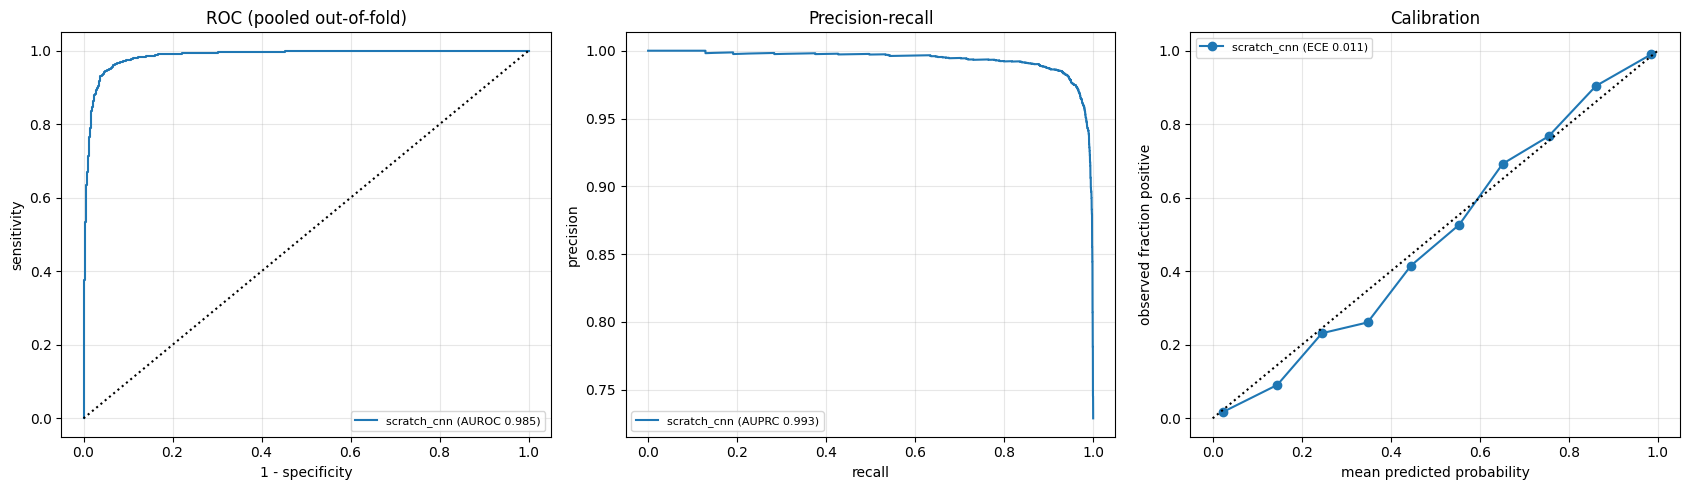

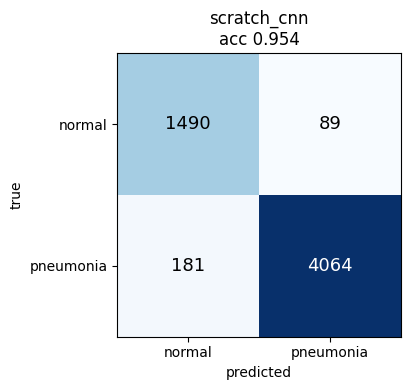

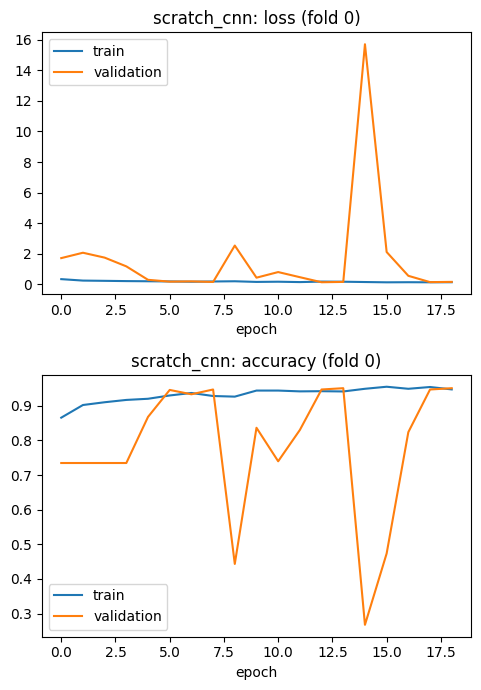

In [20]:
make_figures(res, histories)

### Step 7. Shortcut probes

In [21]:
probes = shortcut_probes(df, G64, y, groups, res) if CFG.RUN_PROBES else None
display(probes)

None

### Step 8. Your original setup, corrected (official train -> official test)

In [25]:
official = official_split_eval(df, X, y, groups) if CFG.RUN_OFFICIAL_SPLIT else None
display(official)

17:06:03 547 train/val images share a patient or near-duplicate group with the official test set and were removed from training.
17:13:25   official split scratch_cnn     AUROC 0.943  Acc@0.5 0.777


,model,n_test,n_train_images_used,n_removed_for_overlap,AUROC,AUROC_lo,AUROC_hi,Sens,Sens_lo,Sens_hi,...,Spec_hi,PPV,PPV_lo,PPV_hi,Acc_youden,Acc_youden_lo,Acc_youden_hi,Acc_at_0.5,Acc_at_0.5_lo,Acc_at_0.5_hi
0,scratch_cnn,618,4659,547,0.942627,0.922856,0.961001,0.989664,0.977958,0.997608,...,0.653854,0.802935,0.754457,0.845386,0.841424,0.808433,0.872783,0.776699,0.73411,0.815754


### Step 9. External validation (runs only if EXTERNAL is set)

In [26]:
external = external_validation(df, X, G64, H, y, groups, res)
display(external)

17:17:27 No external dataset configured (CFG.EXTERNAL is None). Skipping.


None

### Step 10. Export everything and print the paper-ready text

In [27]:
ms = export_all(df, X, audit, res, folds_df, probes, None, external)
append_official_snippets(official, overlap)
display(ms)
print(open(OUT / "paper_snippets.md").read())

17:17:37 All outputs are in results_scratch


,params,pretrained_weights_loaded,mean_epochs,total_seconds
model,,,,
scratch_cnn,1176353,False,15.8,3131.2


# Paper-ready text for `pneumonia` (generated by the notebook; check every number before use)

## Dataset and splits

We used 5824 images (4245 pneumonia, 1579 normal; prevalence 72.9%). 5888 exact duplicate files were removed. Near-duplicates were found with a 256-bit difference hash followed by a pixel-correlation check (r >= 0.97): 0 pairs, 4507 images in multi-image groups. All images of a group were always kept in the same fold. Patient identifiers parsed from the file names were used to keep a patient's images in one fold.

## Protocol

Stratified, group-aware 5-fold cross-validation. Inside each training portion about one sixth was held out as a validation set used only for early stopping (patience 6 on validation loss) and for choosing the decision threshold; the test fold was never used for any decision. Class imbalance was handled with class weights; no oversampling was used. Augmentation: small rotation, translation, zoom and contrast changes, no flips. Adam (learning rate 0

## Where each output goes in the paper

| Output file (in `results/`) | Use it for |
|---|---|
| `tables/table_main_val_youden.csv`, `table_main.tex` | Pneumonia performance table (patient-grouped CV, 95% CIs) |
| `tables/official_split_eval.csv` | Number comparable to earlier work (official train -> official test), with the fixes |
| `tables/official_split_overlap.json` | Reviewer point 2: do the official folders share patients or near-copies? |
| `figures/confusion_matrices.png`, `learning_curves_fold0.png`, `roc_pr_calibration.png` | Replace the pneumonia matrix and curve figures (Fig 5 and Fig 9 in the old draft) |
| `tables/duplicate_audit.json`, `figures/dup_examples.png`, `data/split_manifest.csv` | Reviewer point 2 |
| `tables/shortcut_probes.csv`, `figures/shortcut_probes.png` | Reviewer point 5 |
| `tables/models_summary.csv`, `data/config.json`, `data/environment.json` | Reviewer point 3 |
| `tables/predictions_oof.csv` | Single source of truth for every number and figure |
| `paper_snippets.md` | Draft Methods / Results / Limitations text with real numbers. Check every number |

Download `results_pneumonia.zip` from the Output tab when the run finishes.
